# Eigenschaften der CSV-Dateien filtern.
Ein paar Worte vorab:<br>
Bei der Filterung der Tabellen nach Äquivalenzrelationen sollte folgende vorab klargestellt werden, damit dies im Verlauf nicht zu Irritationen führen soll:<br>
Wenn zwei Dozenten/Lehrveranstaltungen unter einem Aspekt verglichen werden und dies in einer Äquivalenzrelationen wiedergegeben werden soll, so müssten zwar folgende Eigenschaften bei der (Teil-)Relation dargestellt werden:<br>
`    ` • Reflexivität "REF"<br>
`    ` • Symmetrie "SYM"<br>
`    ` • Transitivität "TRA"<br>
Im folgenden Code ist keine Funktion geben, was auf Reflexivität prüfen soll. Dieser Gedankengang wird zwar näher in der Arbeit erklärt (Verweise auf *"kommt noch"*).<br>
Der Grund kann grob folgendermaßen beschrieben werden, und zwar ist die Reflexivität im Kontext unserer Daten schon implizit enthalten, denn trotz fehlenden Einträgen in der Diagonalen, so wird gut wir er/sie selbst sein und die Antwortmöglicheten auf den Fragen bieten nichts anderes zu.

# Importe

In [1]:
import itertools
import ipywidgets as widgets
import matplotlib
import multiprocessing as mp
import os
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import random
import scipy
import sys
import warnings
import webbrowser

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx

from ipywidgets import interact, IntSlider, Output
from IPython.display import display,HTML
from itertools import product, permutations
from multiprocessing import Pool, cpu_count
from scipy.optimize import dual_annealing


# Print versions of the libraries
print(f"Python version: {sys.version}\n")

print(f"Itertools module: Built-in, no version")
print(f"Multiprocessing module: Built-in, no version")
print(f"Random module: Built-in, no version\n")

print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scipy version: {scipy.__version__}")

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.projections")

Python version: 3.10.12 (main, Feb  4 2025, 14:57:36) [GCC 11.4.0]

Itertools module: Built-in, no version
Multiprocessing module: Built-in, no version
Random module: Built-in, no version

Matplotlib version: 3.6.3
Numpy version: 1.26.4
Pandas version: 2.2.3
Scipy version: 1.14.1


### Filterung der Teilmenge, die der Regel der Transitivität & Symmetrie folgen. Dies erfolgt mittels Prinzipien der "vectorize operations". (Vektoroperationen)
Das ist mir tatsächlich wegen einem Post in LinkedIn wieder eingefallen, denn zum einen wurde dies schon eins in der Vorlesung "Complexity, Randomisation, Aproximation and CAP-Learning" angesprochen und ist bei dem Datensatz "LP_Verständlichkeit" schneller gegenüber von multiprocessing.

### Funktionen

In [2]:
# Vektorisierte Transitivitätsprüfung

def is_transitive_vectorized(matrix, binaer:bool=False) -> bool:
    """
    Prüft, ob eine gegebene Relation (als Matrix dargestellt) transitiv ist.

    Args:
        matrix (np.ndarray): Eine quadratische Matrix, die eine Relation darstellt.
        binaer (bool): Wenn True, wird die Matrix in eine boolesche Matrix (0/1) umgewandelt.

    Returns:
        bool: True, wenn die Relation transitiv ist, andernfalls False.
    """
    if binaer:
        # Stellt sicher, dass die Matrix boolesch interpretiert wird
        matrix = (matrix > 0).astype(int)
    
    # Berechne die quadratische Matrix
    matrix_squared = np.dot(matrix, matrix) > 0
    
    # Rückgabe und Überprüfen, ob alle Pfade aus matrix_squared auch in der ursprünglichen Matrix sind.
    return np.all((matrix_squared & (matrix == 0)) == False)

matrix = np.array([ [1, 1, 1], [0, 1, 1], [0, 0, 1] ])
print(is_transitive_vectorized(matrix)) # True

matrix = np.array([ [1, 1, 0], [0, 1, 1], [0, 0, 1] ])
print(is_transitive_vectorized(matrix)) # False

matrix = np.array([ [1, 18, 5], [0, 1, 27], [0, 0, 1] ])
print(is_transitive_vectorized(matrix, binaer=False)) # True

matrix = np.array([ [1, 18, 5], [0, 1, 27], [0, 0, 1] ])
print(is_transitive_vectorized(matrix, binaer=True)) # True

True
False
True
True


In [3]:
# Vektorisierte Symmetrieprüfung

def is_symmetric_vectorized(matrix: np.array, atol: float=0, rtol: float=0.01) -> bool:
    """
    Prüft, ob eine gegebene quadratische Matrix symmetrisch ist,
    wobei sowohl eine absolute (atol) als auch eine relative (rtol)
    Abweichung zwischen Elementen erlaubt ist – unabhängig vom Datentyp.

    Zwei Elemente a und b gelten als "nahe", wenn gilt:
        |a - b| <= atol + rtol * max(|a|, |b|)

    Parameter:
    ----------
    matrix : np.ndarray
        Die zu prüfende (quadratische) Matrix.
    atol : float, optional
        Die maximal erlaubte absolute Abweichung (Standard: 0).
    rtol : float, optional
        Die maximal erlaubte relative Abweichung (Standard: 0.01 = 1%).

    Rückgabe:
    ---------
    bool
        True, wenn die Matrix innerhalb der Toleranzen symmetrisch ist, sonst False.
    """
    a = matrix
    b = matrix.T

    # Berechne Differenz
    diff = np.abs(a - b)
    max_vals = np.maximum(np.abs(a), np.abs(b))

    # Bedingung: diff <= atol + rtol * max(|a|, |b|)
    return np.all(diff <= (atol + rtol * max_vals))

A = np.array([[1, 100], [101, 1]])

# Absolut 1 Unterschied, aber relativ ~1% Abweichung → True bei ausreichender Toleranz
print(is_symmetric_vectorized(A, atol=1, rtol=0.02))  # True

# Kleinere Toleranzen → False
print(is_symmetric_vectorized(A, atol=0, rtol=0.005))  # False

True
False


In [4]:
# Sliding Window zur Suche nach symmetrischen und transitiven Teilmatrizen

def find_symmetric_transitive_submatrices(matrix, min_size=2, max_size=10) -> np.array:
    """
    Findet alle quadratischen Teilmatrizen einer gegebenen Matrix, die sowohl symmetrisch 
    als auch transitiv sind.

    Durchsucht die gegebene Matrix nach allen möglichen Teilmatrizen mit einer Kantenlänge 
    zwischen `min_size` und `max_size`. Jede gefundene Teilmatrix wird auf Symmetrie und 
    Transitivität geprüft. Positionen aller gültigen Teilmatrizen werden zurückgegeben.

    Parameter
    ----------
    matrix : np.ndarray
        Eine quadratische Eingabematrix (2D NumPy-Array), die untersucht werden soll.
    min_size : int, optional
        Die minimale Größe der zu betrachtenden Teilmatrizen (Standard ist 2).
    max_size : int, optional
        Die maximale Größe der zu betrachtenden Teilmatrizen (Standard ist 10).

    Rückgabe
    --------
    list
        Eine Liste mit zwei Einträgen:
        - Eine Liste von Tupeln, die die Koordinaten der gültigen Teilmatrizen enthalten.
          Jedes Tupel besteht aus zwei weiteren Tupeln: ((start_row, end_row), (start_col, end_col)).
        - Die Gesamtanzahl der gefundenen symmetrisch-transitiven Teilmatrizen.
    """
    count = 0
    n = matrix.shape[0]
    symmetric_transitive_submatrices = []
    
    for size in range(min_size, min(max_size, n) + 1):
        for i in range(n - size + 1):
            for j in range(n - size + 1):
                submatrix = matrix[i:i+size, j:j+size]
                if is_symmetric_vectorized(matrix=submatrix, rtol=0.025) and is_transitive_vectorized(submatrix):
                    symmetric_transitive_submatrices.append(((i, i+size), (j, j+size)))
                    count += 1
                    
    return [symmetric_transitive_submatrices, count]

matrix = np.array([ [1, 1, 0, 0], [1, 1, 0, 0], [0, 0, 1, 1], [0, 0, 1, 1] ])
result, count = find_symmetric_transitive_submatrices(matrix, min_size=2, max_size=3)

# Zwei 2x2 Blöcke an (0,0)-(2,2) und (2,2)-(4,4)
print(count >= 2)
print("Gefundene Submatrizen:", result)

True
Gefundene Submatrizen: [((0, 2), (0, 2)), ((0, 2), (2, 4)), ((1, 3), (1, 3)), ((2, 4), (0, 2)), ((2, 4), (2, 4)), ((0, 3), (0, 3)), ((1, 4), (1, 4))]


## DataFrame laden

In [5]:
# Load the CSV file
file_path = 'CSVs/data_generated/LP_Verständlichkeit.csv'
df_orginal = pd.read_csv(file_path, header=None)

for i in range(min(df_orginal.shape)):
    df_orginal.iat[i, i] = 1

# Binäre Umwandlung (z.B., alle Werte > 0 zu 1, sonst 0)
df_binaer = (df_orginal > 0).astype(int)

# Selbe df spaeter wichtig
#df = (df_orginal > 0).astype(int)

# Display the first few rows of the matrix to understand its structure
df_binaer.head()
df_orginal.head()

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,1,7,4,4,3,7,4,12,6,7,...,12,6,8,10,6,5,9,11,6,9
1,2,1,5,10,8,9,7,4,4,6,...,11,8,5,4,5,12,3,6,11,4
2,8,4,1,4,3,9,7,8,7,9,...,3,7,5,9,5,6,9,9,3,7
3,10,9,6,1,10,4,9,3,3,13,...,6,8,8,8,6,4,2,16,8,6
4,6,9,6,10,1,6,6,5,11,2,...,5,2,5,9,6,8,11,10,6,6


### Anwendung

In [6]:
# Binaer
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
matrix_np_binaer = df_binaer.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe m, also so groß wie die Matrix selbst, jedoch kam es nicht zu Ordnungen über die 10)
symmetric_transitive_submatrices_binaer = find_symmetric_transitive_submatrices(matrix_np_binaer, min_size=2, max_size=df_binaer.shape[1])[0]

# Ausgabe der ersten 5 gefundenen Bereiche
print(f"Die ersten 5 symmetrischen und transtiven Matrizen:\n{symmetric_transitive_submatrices_binaer[:5]}")


# Orginal
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
matrix_np_orginal = df_orginal.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe m, also so groß wie die Matrix selbst, jedoch kam es nicht zu Ordnungen über die 10)
symmetric_transitive_submatrices_orginal = find_symmetric_transitive_submatrices(matrix_np_orginal, min_size=2, max_size=df_orginal.shape[1])[0]

# Ausgabe der ersten 5 gefundenen Bereiche
print(f"Die ersten 5 symmetrischen und transtiven Matrizen:\n{symmetric_transitive_submatrices_orginal[:5]}")

Die ersten 5 symmetrischen und transtiven Matrizen:
[((0, 2), (0, 2)), ((0, 2), (1, 3)), ((0, 2), (2, 4)), ((0, 2), (3, 5)), ((0, 2), (4, 6))]
Die ersten 5 symmetrischen und transtiven Matrizen:
[((0, 2), (11, 13)), ((0, 2), (12, 14)), ((0, 2), (13, 15)), ((0, 2), (40, 42)), ((0, 2), (43, 45))]


============================================================================================================================================================================================================================================================================================================
### Es folgt eine Aussortierung der Matrizen, die sich nicht an der Diagonalen befinden, da die geschriebene Funktion zwar bei übergebene Matrizen die Eigenschaften TRA und SYM richtig findet, aber bei Teilmatrizen die Symmetrie (wegen der eigenen Regel) nur dann garanitert werden kann, wenn wenn es sich an der Diagonale befindet.
Die größtmöglichen Quadrate an der Diagonale zu finden, ist dowieso das Ziel um Äquivalenzklassen bilden zu können.

In [7]:
# Binaer
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
symmetric_transitive_same_rows_cols_binaer = [
    (rows, cols) for rows, cols in symmetric_transitive_submatrices_binaer if rows == cols
]

# Ausgabe der ersten 5 gefundenen Bereiche, die an der Hauptdiagonalen sind
print(f"Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:\n{symmetric_transitive_same_rows_cols_binaer[:5]}")



# Orginal
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
symmetric_transitive_same_rows_cols_orginal = [
    (rows, cols) for rows, cols in symmetric_transitive_submatrices_orginal if rows == cols
]

# Ausgabe der ersten 5 gefundenen Bereiche, die an der Hauptdiagonalen sind
print(f"Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:\n{symmetric_transitive_same_rows_cols_orginal[:5]}")

Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:
[((0, 2), (0, 2)), ((1, 3), (1, 3)), ((2, 4), (2, 4)), ((3, 5), (3, 5)), ((4, 6), (4, 6))]
Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:
[((3, 5), (3, 5)), ((10, 12), (10, 12)), ((11, 13), (11, 13)), ((19, 21), (19, 21)), ((22, 24), (22, 24))]


In [8]:
#print(symmetric_transitive_same_rows_cols_binaer, "\n")
print(symmetric_transitive_same_rows_cols_orginal)

[((3, 5), (3, 5)), ((10, 12), (10, 12)), ((11, 13), (11, 13)), ((19, 21), (19, 21)), ((22, 24), (22, 24)), ((34, 36), (34, 36)), ((35, 37), (35, 37)), ((43, 45), (43, 45)), ((58, 60), (58, 60)), ((69, 71), (69, 71)), ((70, 72), (70, 72)), ((75, 77), (75, 77)), ((77, 79), (77, 79)), ((78, 80), (78, 80)), ((83, 85), (83, 85)), ((84, 86), (84, 86)), ((85, 87), (85, 87)), ((88, 90), (88, 90)), ((91, 93), (91, 93)), ((84, 87), (84, 87))]


In [9]:
# Binaer
# Array für die gesammelten DataFrame-Ausschnitte
intervalle_binaer = []

length=len(symmetric_transitive_same_rows_cols_binaer)

# Schleife zum Sammeln der Ausschnitte
for l in range(length):
    intervalle_binaer.append(symmetric_transitive_same_rows_cols_binaer[l][0])

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
intervalle_np_binaer = np.array(intervalle_binaer, dtype=object)
intervalle_binaer


# Orginal
# Array für die gesammelten DataFrame-Ausschnitte
intervalle_orginal = []

length=len(symmetric_transitive_same_rows_cols_orginal)

# Schleife zum Sammeln der Ausschnitte
for l in range(length):
    intervalle_orginal.append(symmetric_transitive_same_rows_cols_orginal[l][0])

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
intervalle_np_orginal = np.array(intervalle_orginal, dtype=object)
intervalle_orginal

[(3, 5),
 (10, 12),
 (11, 13),
 (19, 21),
 (22, 24),
 (34, 36),
 (35, 37),
 (43, 45),
 (58, 60),
 (69, 71),
 (70, 72),
 (75, 77),
 (77, 79),
 (78, 80),
 (83, 85),
 (84, 86),
 (85, 87),
 (88, 90),
 (91, 93),
 (84, 87)]

In [10]:
# Hilfsfunktion zum Überprüfen von Überlappungen
def ueberlappen(interval1, interval2):
    return interval1[1] >= interval2[0] and interval2[1] >= interval1[0]

# Äquivalenzklassen erstellen
def bilde_aequivalenzklassen(intervalle):
    intervalle = sorted(intervalle)
    klassen = []

    while intervalle:
        aktuelle_klasse = [intervalle.pop(0)]
        i = 0

        while i < len(intervalle):
            if any(ueberlappen(interval, intervalle[i]) for interval in aktuelle_klasse):
                aktuelle_klasse.append(intervalle.pop(i))
            else:
                i += 1

        klassen.append(aktuelle_klasse)

    return klassen

In [11]:
# Binaer
# Äquivalenzklassen berechnen
aequivalenzklassen_binaer = bilde_aequivalenzklassen(intervalle_binaer)

# Ausgabe als DataFrame für Übersicht
df_aequivalenzklassen_binaer = pd.DataFrame({'Äquivalenzklasse': range(1, len(aequivalenzklassen_binaer)+1), 'Intervalle': aequivalenzklassen_binaer})

print(df_aequivalenzklassen_binaer)

   Äquivalenzklasse                                         Intervalle
0                 1  [(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7...


In [12]:
# Orginal
# Äquivalenzklassen berechnen
aequivalenzklassen_orginal = bilde_aequivalenzklassen(intervalle_orginal)
print(aequivalenzklassen_orginal)

# Ausgabe als DataFrame für Übersicht
df_aequivalenzklassen_orginal = pd.DataFrame({'Äquivalenzklasse': range(1, len(aequivalenzklassen_orginal)+1), 'Intervalle': aequivalenzklassen_orginal})

print(df_aequivalenzklassen_orginal)

[[(3, 5)], [(10, 12), (11, 13)], [(19, 21)], [(22, 24)], [(34, 36), (35, 37)], [(43, 45)], [(58, 60)], [(69, 71), (70, 72)], [(75, 77), (77, 79), (78, 80)], [(83, 85), (84, 86), (84, 87), (85, 87)], [(88, 90)], [(91, 93)]]
    Äquivalenzklasse                                Intervalle
0                  1                                  [(3, 5)]
1                  2                      [(10, 12), (11, 13)]
2                  3                                [(19, 21)]
3                  4                                [(22, 24)]
4                  5                      [(34, 36), (35, 37)]
5                  6                                [(43, 45)]
6                  7                                [(58, 60)]
7                  8                      [(69, 71), (70, 72)]
8                  9            [(75, 77), (77, 79), (78, 80)]
9                 10  [(83, 85), (84, 86), (84, 87), (85, 87)]
10                11                                [(88, 90)]
11                12 

In [13]:
def plot_eq_1(aequivalenzklassen, titelerweiterung:str=""):
    # Visualisierung der Äquivalenzklassen als Balkendiagramm
    
    # Farben für verschiedene Äquivalenzklassen
    farben = plt.cm.tab20.colors
    
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot der Intervalle für jede Äquivalenzklasse
    for i, klasse in enumerate(aequivalenzklassen):
        for interval in klasse:
            ax.plot([interval[0], interval[1]], [i, i], marker='o', linewidth=6, color=farben[i % len(farben)])
    
    # Achsentitel und Beschriftungen
    ax.set_yticks(range(len(aequivalenzklassen)))
    ax.set_yticklabels([f'Klasse {i+1}' for i in range(len(aequivalenzklassen))])
    ax.set_xlabel('Wertebereich')
    ax.set_ylabel('Äquivalenzklassen')
    ax.set_title('Visualisierung der Äquivalenzklassen: ' + titelerweiterung)
    
    # Legende hinzufügen
    legenden_patches = [mpatches.Patch(color=farben[i % len(farben)], label=f'Klasse {i+1}') for i in range(len(aequivalenzklassen))]
    ax.legend(handles=legenden_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

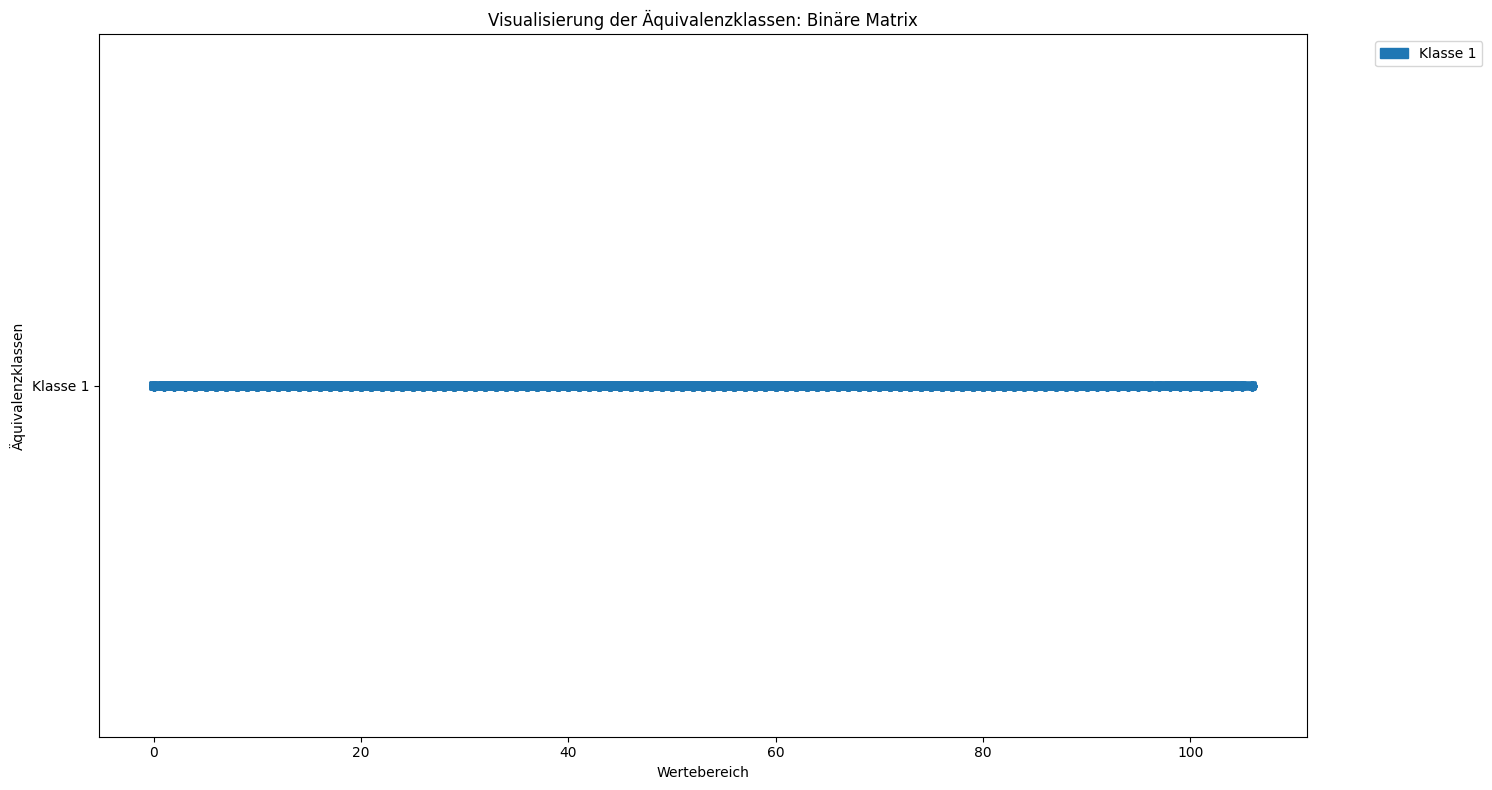

In [14]:
plot_eq_1(aequivalenzklassen_binaer, "Binäre Matrix")

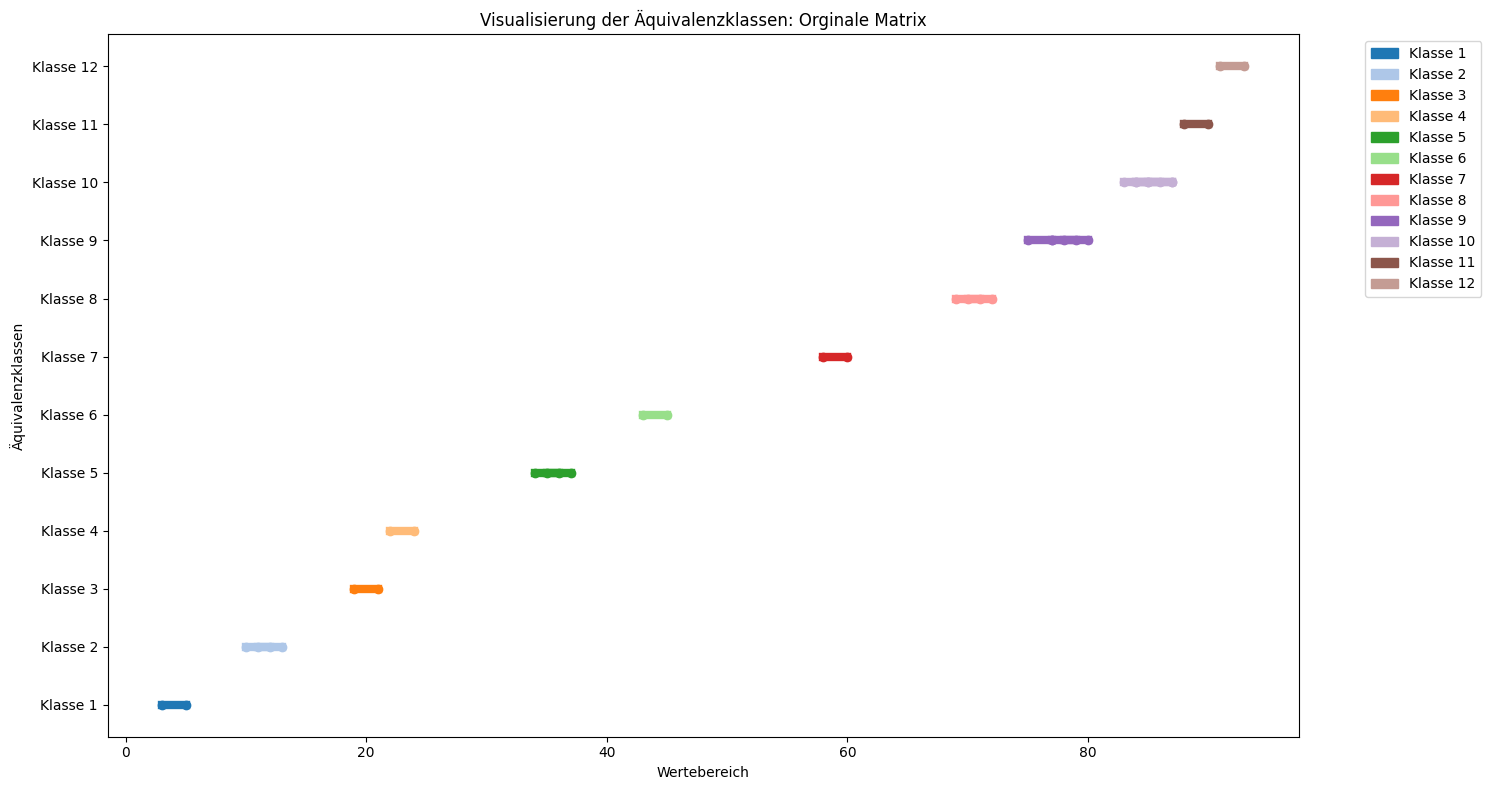

In [15]:
plot_eq_1(aequivalenzklassen_orginal, "Orginale Matrix")

In [16]:
def plot_eq_2(matrix_np, aequivalenz_df, titelerweiterung:str=""):
    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.imshow(matrix_np, cmap='Greys', interpolation='none')
    fig.colorbar(cax, label='Relation (0/1)')
    ax.set_title("Adjazenzmatrix: " + titelerweiterung)
    ax.set_xlabel("Knoten")
    ax.set_ylabel("Knoten")

    # Alle Intervalle durchgehen und Rechtecke zeichnen
    for _, row in aequivalenz_df.iterrows():
        intervalle = row['Intervalle']
        for (start, end) in intervalle:
            size = end - start + 1
            rect = mpatches.Rectangle(
                (start, start), size, size,
                linewidth=1.5, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

    plt.show()

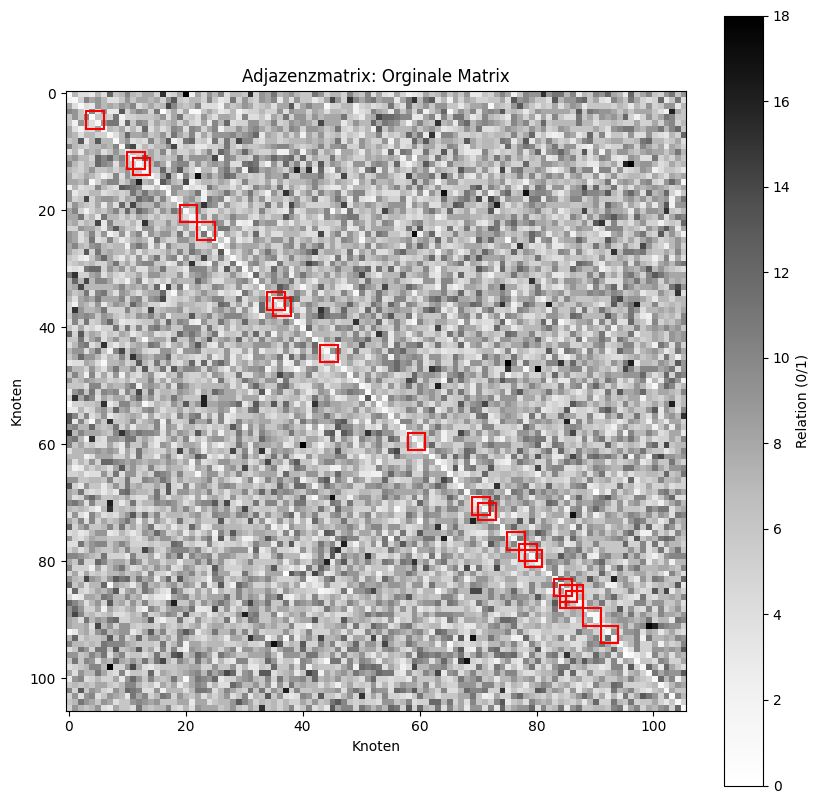

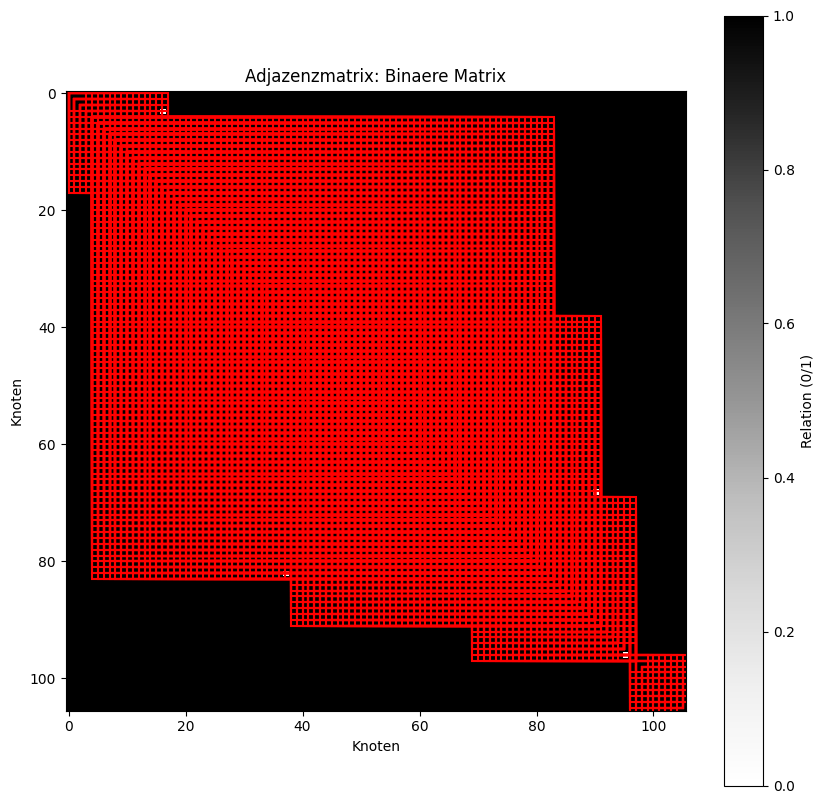

In [17]:
plot_eq_2(matrix_np_orginal, df_aequivalenzklassen_orginal, "Orginale Matrix")
plot_eq_2(matrix_np_binaer, df_aequivalenzklassen_binaer, "Binaere Matrix")

In [18]:
def plot_eq_1_plotly(matrix:pd.DataFrame, html_name:str):
    pio.renderers.default = 'iframe_connected'  # Alternativ: 'iframe_connected', 'browser'
    
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])

    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)

    # Effizientere Entfernung transitiver Kanten
    transitive_edges = set()

    # Kantenliste extrahieren
    all_edges = [(u, v, matrix_clean.loc[u, v]) for u, v in G.edges()]

    # Rangordnung nach eingehendem Gewicht
    incoming_weights = {n: 0 for n in G.nodes()}
    for u, v, w in all_edges:
        incoming_weights[v] += w
    
    # Sortiere Knoten nach Rang
    sorted_nodes = sorted(incoming_weights.items(), key=lambda x: -x[1])
    node_order = [node for node, _ in sorted_nodes]
    
    # Manuelle Positionierung (x = gleichmäßig, y = nach Rang)
    pos = {node: (i, len(node_order)-rank) for rank, (i, node) in enumerate(zip(range(len(node_order)), node_order))}


    try:
        pos = nx.planar_layout(G)
    except:
        pos = nx.spring_layout(G, seed=42)

    all_edges = [(u, v, matrix.loc[u, v]) for u, v in G.edges()]

    def plot_filtered_graph(threshold):
        edge_x = []
        edge_y = []
        edge_labels = []

        for u, v, w in all_edges:
            if w >= threshold:
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
                edge_labels.append(f"{u} → {v}: {w}")

        if not edge_labels:
            print(f"Keine Kanten ≥ {threshold}")
            return

        edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='gray'))

        node_x = [pos[n][0] for n in G.nodes()]
        node_y = [pos[n][1] for n in G.nodes()]
        node_text = [str(n) for n in G.nodes()]

        node_trace = go.Scatter(
            x=node_x, y=node_y, text=node_text,
            mode='markers+text', textposition='top center',
            marker=dict(size=20, color='skyblue', line=dict(width=2, color='black'))
        )

        fig = go.Figure(data=[edge_trace, node_trace])
        fig.update_layout(
            title=f'Graph mit Kanten ≥ {threshold}',
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )
        
        # Immer auch als HTML speichern (z. B. für Export/Archivierung)
        file_path = os.path.abspath(html_name)
        fig.write_html(file_path)

    max_weight = int(matrix.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=4))

In [19]:
# Angenommen df_matrix ist deine Adjazenzmatrix (Pandas DataFrame)
df_matrix = df_orginal
adj = df_matrix.to_numpy()
n = adj.shape[0]

# Erstelle Graph aus Matrix
G = nx.DiGraph()
for i in range(n):
    for j in range(n):
        if not np.isnan(adj[i, j]) and adj[i, j] != 0:
            G.add_edge(i, j, weight=adj[i, j])

# Floyd-Warshall: Alle kürzesten Pfade
shortest_paths = dict(nx.floyd_warshall(G, weight='weight'))

# Finde transitive Kanten
to_remove = []
for u, v, data in G.edges(data=True):
    direct_weight = data["weight"]
    for k in range(n):
        if k != u and k != v:
            try:
                alt_path = shortest_paths[u][k] + shortest_paths[k][v]
                if alt_path <= direct_weight:
                    to_remove.append((u, v))
                    break  # eine Abkürzung reicht
            except KeyError:
                continue

# Entferne transitive Kanten
G.remove_edges_from(to_remove)

# Optional: Neue Matrix aus dem reduzierten Graphen erzeugen
new_matrix = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    new_matrix[u, v] = data["weight"]

df_reduced = pd.DataFrame(new_matrix)
df_reduced

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,1.0,0.0,4.0,4.0,3.0,0.0,4.0,0.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1.0,5.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,...,0.0,0.0,5.0,4.0,5.0,0.0,3.0,0.0,0.0,4.0
2,0.0,4.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,3.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,6.0,0.0,0.0,2.0,...,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,5.0,0.0,5.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0
102,0.0,5.0,0.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,...,0.0,6.0,4.0,3.0,0.0,0.0,1.0,0.0,6.0,6.0
103,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,6.0,...,0.0,5.0,0.0,0.0,0.0,5.0,3.0,6.0,1.0,5.0


In [34]:
plot_eq_1_plotly(df_reduced, "01_Plotly_Äquivalenzen_reduced_groß.html")
HTML('<a href="01_Plotly_Äquivalenzen_reduced.html" target="_blank">Öffne Plot in neuem Tab</a>')

NameError: name 'IFrame' is not defined

interactive(children=(IntSlider(value=4, description='threshold', max=7), Output()), _dom_classes=('widget-int…

In [33]:
matrix_clean = remove_transitive_edges_parallel(df_orginal)
G = nx.from_pandas_adjacency(matrix_clean, create_using=nx.DiGraph)
nx.to_pandas_adjacency(G).head()

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0
3,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0
4,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0


In [35]:
plot_eq_1_plotly(matrix_clean, "01_Plotly_Äquivalenzen_clean_groß.html")
HTML('<a href="01_Plotly_Äquivalenzen_clean.html" target="_blank">Öffne Plot in neuem Tab</a>')

NameError: name 'IFrame' is not defined

interactive(children=(IntSlider(value=4, description='threshold', max=18), Output()), _dom_classes=('widget-in…

In [52]:
plot_eq_1_plotly(df_orginal, "01_Plotly_Äquivalenzen_Orginal_groß.html")
HTML('<a href="01_Plotly_Äquivalenzen_Orginal.html" target="_blank">Öffne Plot in neuem Tab</a>')

NameError: name 'IFrame' is not defined

interactive(children=(IntSlider(value=4, description='threshold', max=18), Output()), _dom_classes=('widget-in…

In [53]:
plot_eq_1_plotly(df_binaer, "02_Plotly_Äquivalenzen_Binaer_groß.html")
HTML('<a href="02_Plotly_Äquivalenzen_Binaer.html" target="_blank">Öffne Plot in neuem Tab</a>')

NameError: name 'IFrame' is not defined

interactive(children=(IntSlider(value=1, description='threshold', max=1), Output()), _dom_classes=('widget-int…

In [49]:
def plot_eq_2_plotly(matrix:pd.DataFrame, html_name:str):
    pio.renderers.default = 'iframe_connected'  # Alternativ: 'iframe_connected', 'browser'
    
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])

    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)

    # Effizientere Entfernung transitiver Kanten
    transitive_edges = set()

    # Kantenliste extrahieren
    all_edges = [(u, v, matrix_clean.loc[u, v]) for u, v in G.edges()]

    # Rangordnung nach eingehendem Gewicht
    incoming_weights = {n: 0 for n in G.nodes()}
    for u, v, w in all_edges:
        incoming_weights[v] += w
    
    # Sortiere Knoten nach Rang
    sorted_nodes = sorted(incoming_weights.items(), key=lambda x: -x[1])
    node_order = [node for node, _ in sorted_nodes]
    
    # Manuelle Positionierung (x = gleichmäßig, y = nach Rang)
    pos = {node: (i, len(node_order)-rank) for rank, (i, node) in enumerate(zip(range(len(node_order)), node_order))}


    try:
        pos = nx.planar_layout(G)
    except:
        pos = nx.spring_layout(G, seed=42)

    all_edges = [(u, v, matrix.loc[u, v]) for u, v in G.edges()]

    def plot_filtered_graph(threshold):
        edge_x = []
        edge_y = []
        edge_labels = []
        active_nodes = set()
    
        for u, v, w in all_edges:
            if w >= threshold:
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
                edge_labels.append(f"{u} → {v}: {w}")
                active_nodes.update([u, v])  # Nur diese Knoten anzeigen
    
        if not edge_labels:
            print(f"Keine Kanten ≥ {threshold}")
            return
    
        edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='gray'))
    
        node_x = [pos[n][0] for n in active_nodes]
        node_y = [pos[n][1] for n in active_nodes]
        node_text = [str(n) for n in active_nodes]
    
        node_trace = go.Scatter(
            x=node_x, y=node_y, text=node_text,
            mode='markers+text', textposition='top center',
            marker=dict(size=20, color='skyblue', line=dict(width=2, color='black'))
        )
    
        fig = go.Figure(data=[edge_trace, node_trace])
        fig.update_layout(
            title=f'Graph mit Kanten ≥ {threshold}',
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )
    
        file_path = os.path.abspath(html_name)
        fig.write_html(file_path)

    max_weight = int(matrix.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=5))

In [50]:
plot_eq_2_plotly(df_reduced, "02_Plotly_Äquivalenzen_reduced_groß.html")
HTML('<a href="02_Plotly_Äquivalenzen_reduced.html" target="_blank">Öffne Plot in neuem Tab</a>')

interactive(children=(IntSlider(value=5, description='threshold', max=7), Output()), _dom_classes=('widget-int…

In [51]:
plot_eq_2_plotly(matrix_clean, "02_Plotly_Äquivalenzen_clean_groß.html")
HTML('<a href="02_Plotly_Äquivalenzen_clean.html" target="_blank">Öffne Plot in neuem Tab</a>')

interactive(children=(IntSlider(value=5, description='threshold', max=18), Output()), _dom_classes=('widget-in…

In [54]:
plot_eq_2_plotly(df_orginal, "01_Plotly_Äquivalenzen_Orginal_groß.html")
HTML('<a href="02_Plotly_Äquivalenzen_Orginal.html" target="_blank">Öffne Plot in neuem Tab</a>')

interactive(children=(IntSlider(value=5, description='threshold', max=18), Output()), _dom_classes=('widget-in…

In [27]:
def plot_eq_3_plotly_clustered(matrix: pd.DataFrame, html_name: str, aequivalenzklassen: list):
    pio.renderers.default = 'iframe_connected'

    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])

    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)
    all_edges = [(u, v, matrix.loc[u, v]) for u, v in G.edges()]

    # Berechne Gewichtseingang pro Knoten (für Hierarchie)
    incoming_weights = {n: 0 for n in G.nodes()}
    for u, v, w in all_edges:
        incoming_weights[v] += w

    # Hierarchische Ordnung: höheres Gewicht = höher
    sorted_nodes = sorted(incoming_weights.items(), key=lambda x: -x[1])
    node_order = [node for node, _ in sorted_nodes]

    # Clusterfarben zuweisen
    cluster_color_map = {}
    cluster_colors = {}
    for idx, cluster in enumerate(aequivalenzklassen):
        color = f"hsl({random.randint(0, 360)},70%,70%)"
        for node in cluster:
            cluster_color_map[node] = idx
            cluster_colors[node] = color

    # Position: x nach Cluster, y nach Rang
    pos = {}
    for rank, node in enumerate(node_order):
        cluster = cluster_color_map.get(node, -1)
        pos[node] = (cluster, len(node_order) - rank)  # x = Cluster, y = Gewichtsrang

    def plot_filtered_graph(threshold):
        edge_x = []
        edge_y = []
        edge_labels = []

        for u, v, w in all_edges:
            if w >= threshold:
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
                edge_labels.append(f"{u} → {v}: {w}")

        edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='gray'))

        node_x = [pos[n][0] for n in G.nodes()]
        node_y = [pos[n][1] for n in G.nodes()]
        node_text = [str(n) for n in G.nodes()]
        node_colors = [cluster_colors.get(n, 'lightgray') for n in G.nodes()]

        node_trace = go.Scatter(
            x=node_x, y=node_y, text=node_text,
            mode='markers+text', textposition='top center',
            marker=dict(size=20, color=node_colors, line=dict(width=2, color='black'))
        )

        fig = go.Figure(data=[edge_trace, node_trace])
        fig.update_layout(
            title=f'Graph mit Kanten ≥ {threshold}',
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )

        file_path = os.path.abspath(html_name)
        fig.write_html(file_path)
        fig.show()

    max_weight = int(matrix.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=4))

In [28]:
# Umwandlung in Mengen von Indizes pro Äquivalenzklasse
aequivalenzklassen = []
for klasse in aequivalenzklassen_orginal:
    indices = set()
    for start, end in klasse:
        indices.update(range(start, end + 1))
    aequivalenzklassen.append(sorted(indices))
    
aequivalenzklassen

[[3, 4, 5],
 [10, 11, 12, 13],
 [19, 20, 21],
 [22, 23, 24],
 [34, 35, 36, 37],
 [43, 44, 45],
 [58, 59, 60],
 [69, 70, 71, 72],
 [75, 76, 77, 78, 79, 80],
 [83, 84, 85, 86, 87],
 [88, 89, 90],
 [91, 92, 93]]

In [29]:
plot_eq_3_plotly_clustered(df_orginal, "03_Plotly_Äquivalenzen_clustered_groß.html", aequivalenzklassen)
HTML('<a href="03_Plotly_Äquivalenzen_clustered_groß.html" target="_blank">Öffne Plot in neuem Tab</a>')

interactive(children=(IntSlider(value=4, description='threshold', max=18), Output()), _dom_classes=('widget-in…

In [32]:
from joblib import Parallel, delayed

def is_transitive(i, j, arr, mode="strict"):
    n = arr.shape[0]
    for k in range(n):
        if k != i and k != j and arr[i, k] > 0 and arr[k, j] > 0:
            indirect_strength = min(arr[i, k], arr[k, j])
            if mode == "strict" and indirect_strength > arr[i, j]:
                return True
            elif mode == "equal" and indirect_strength == arr[i, j]:
                return True
            elif mode == "any":
                return True  # aggressive Modus
    return False



def remove_transitive_edges_parallel(matrix: pd.DataFrame, n_jobs: int = -1) -> pd.DataFrame:
    arr = matrix.to_numpy(copy=True)
    n = arr.shape[0]

    # Liste aller potenziellen Kanten (i,j), die > 0 sind
    edge_indices = [(i, j) for i in range(n) for j in range(n) if arr[i, j] > 0]

    # Prüfe alle Kanten parallel
    redundant_flags = Parallel(n_jobs=n_jobs)(
        delayed(is_transitive)(i, j, arr) for (i, j) in edge_indices
    )

    # Entferne transitive Kanten
    for (flag, (i, j)) in zip(redundant_flags, edge_indices):
        if flag:
            arr[i, j] = 0

    return pd.DataFrame(arr, index=matrix.index, columns=matrix.columns)

In [30]:
def plot_eq_1_plotly(matrix: pd.DataFrame, html_name: str):
    # Entferne transitive Kanten
    matrix_clean = remove_transitive_edges_parallel(matrix)

    # Baue Graph
    G = nx.from_pandas_adjacency(matrix_clean, create_using=nx.DiGraph)

    # Kantenliste extrahieren
    all_edges = [(u, v, matrix_clean.loc[u, v]) for u, v in G.edges()]

    # Berechne eingehendes Gewicht pro Knoten
    incoming_weights = {n: 0 for n in G.nodes()}
    for u, v, w in all_edges:
        incoming_weights[v] += w

    # Sortiere Knoten nach eingehendem Gewicht
    sorted_nodes = sorted(incoming_weights.items(), key=lambda x: -x[1])
    node_order = [node for node, _ in sorted_nodes]

    # Positionierung: x = gleichmäßig, y = Rang
    pos = {node: (i, len(node_order)-rank) for rank, (i, node) in enumerate(zip(range(len(node_order)), node_order))}

    # Plotfunktion mit Schwellenwert
    def plot_filtered_graph(threshold):
        edge_x, edge_y, edge_labels = [], [], []

        for u, v, w in all_edges:
            if w >= threshold:
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
                edge_labels.append(f"{u} → {v}: {w}")

        if not edge_labels:
            print(f"Keine Kanten ≥ {threshold}")
            return

        edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='gray'))

        node_x = [pos[n][0] for n in G.nodes()]
        node_y = [pos[n][1] for n in G.nodes()]
        node_text = [str(n) for n in G.nodes()]

        node_trace = go.Scatter(
            x=node_x, y=node_y, text=node_text,
            mode='markers+text', textposition='top center',
            marker=dict(size=20, color='skyblue', line=dict(width=2, color='black'))
        )

        fig = go.Figure(data=[edge_trace, node_trace])
        fig.update_layout(
            title=f'Graph mit Kanten ≥ {threshold}',
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )

        # HTML speichern
        file_path = os.path.abspath(html_name)
        fig.write_html(file_path)

        # Anzeige im Notebook
        display(IFrame(src=file_path, width='100%', height=600))
        display(HTML(f'<a href="{file_path}" target="_blank">Öffne Plot in neuem Tab</a>'))

    # Interaktiver Slider
    max_weight = int(matrix_clean.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=4))

In [23]:
# Function to remove transitive edges
def remove_transitive_edges(matrix):
    n = matrix.shape[0]
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if matrix[i, k] and matrix[k, j] and i != j:
                    matrix[i, j] = 0
    return matrix

# Remove transitive edges from the matrix
matrix_orginal_no_transitive = remove_transitive_edges(matrix_np_orginal.copy())
matrix_binaer_no_transitive = remove_transitive_edges(matrix_np_binaer.copy())

In [22]:
def plot_eg_3(matrix_no_transitive):
    # Create a NetworkX graph from the adjacency matrix
    G = nx.from_numpy_array(matrix_no_transitive, create_using=nx.DiGraph)
    
    # Plot the graph using a spring layout
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, seed=42)  # Fruchterman-Reingold layout
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=500,
        font_size=8,
        edge_color="gray",
        arrowsize=10,
    )
    plt.title("Netzwerk-Darstellung der Adjazenzmatrix")
    plt.show()

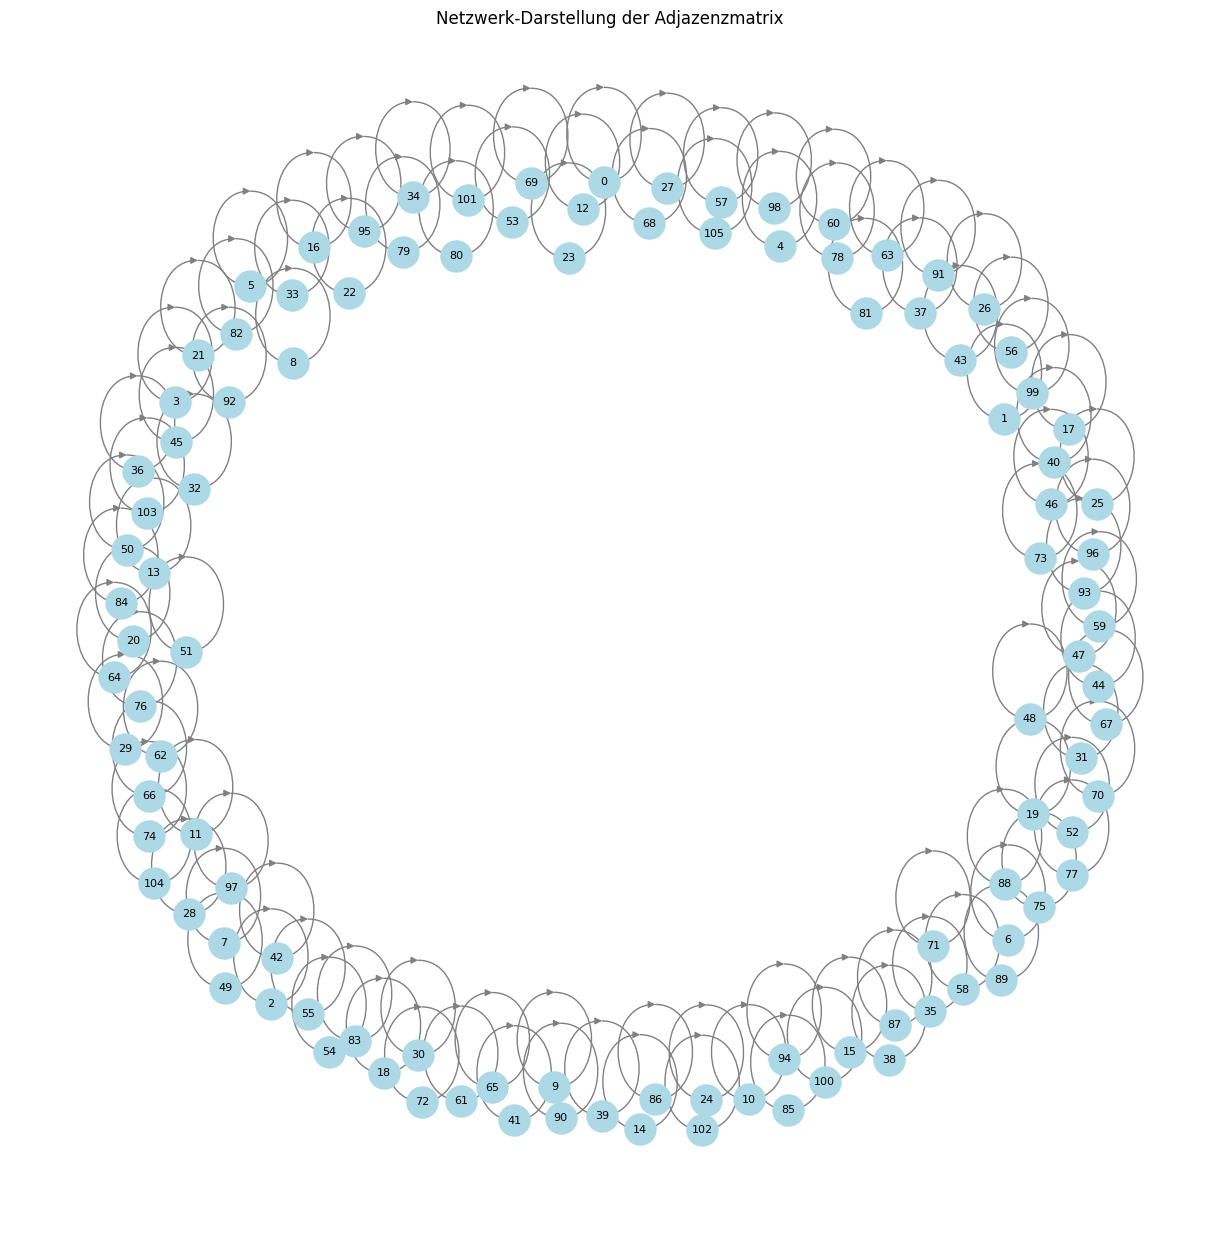

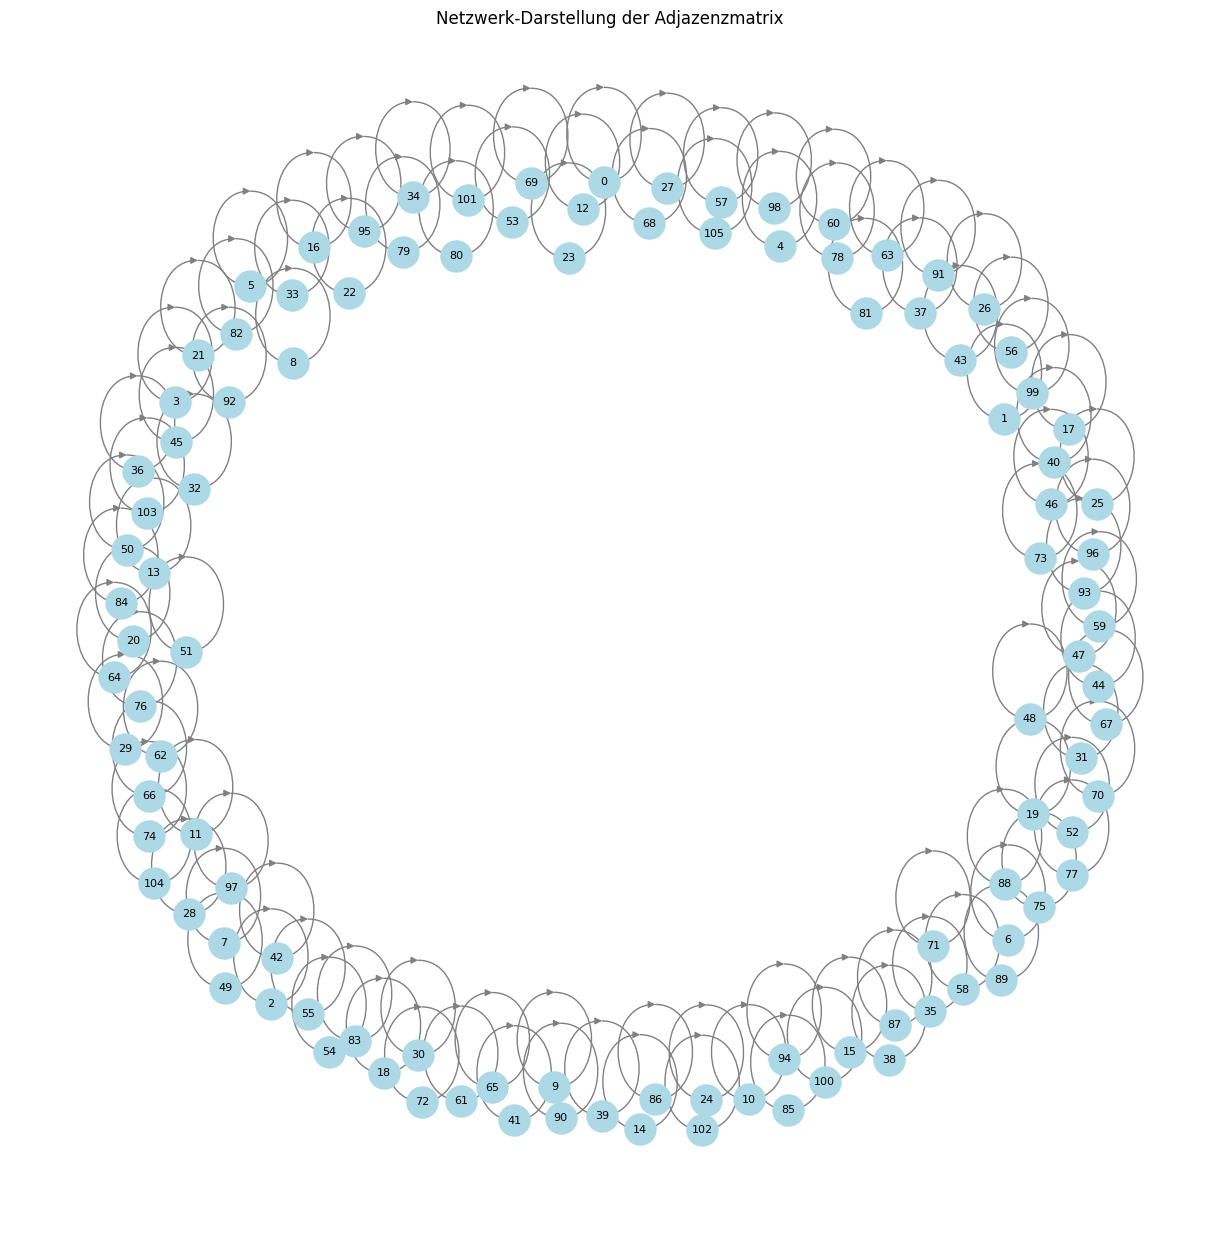

In [24]:
plot_eg_3(matrix_orginal_no_transitive)
plot_eg_3(matrix_binaer_no_transitive)

In [42]:
def plot_eq_4(matrix):
    # Assign default indices and column names if missing
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])
    
    # Create a directed graph from the adjacency matrix
    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)
    
    # Precompute a hierarchical layout for upward direction using topological sort
    try:
        hierarchy = list(nx.topological_sort(G))
        pos = {node: (0, -i) for i, node in enumerate(hierarchy)}
    except nx.NetworkXUnfeasible:
        pos = nx.spring_layout(G, seed=42)
        pos = {node: (x, -y) for node, (x, y) in pos.items()}
    
    # Function to filter edges and nodes based on a threshold
    def plot_filtered_graph(threshold):
        filtered_edges = [(u, v) for u, v, data in G.edges(data=True) if matrix.loc[u, v] >= threshold]
        filtered_nodes = set(u for u, v in filtered_edges).union(v for u, v in filtered_edges)
        
        filtered_G = G.edge_subgraph(filtered_edges).copy()
        
        # Remove isolated nodes
        isolated_nodes = set(filtered_G.nodes) - filtered_nodes
        filtered_G.remove_nodes_from(isolated_nodes)
        
        # Plot the filtered graph
        plt.figure(figsize=(10, 8))
        nx.draw(filtered_G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black', font_weight='bold', edge_color='gray')
        edge_labels = nx.get_edge_attributes(filtered_G, 'weight')
        nx.draw_networkx_edge_labels(filtered_G, pos, edge_labels=edge_labels)
        plt.title(f'Graph with threshold >= {threshold}')
        plt.show()
    
    # Interactive slider for threshold selection
    max_weight = matrix.max().max()
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=int(max_weight), step=1, value=18))

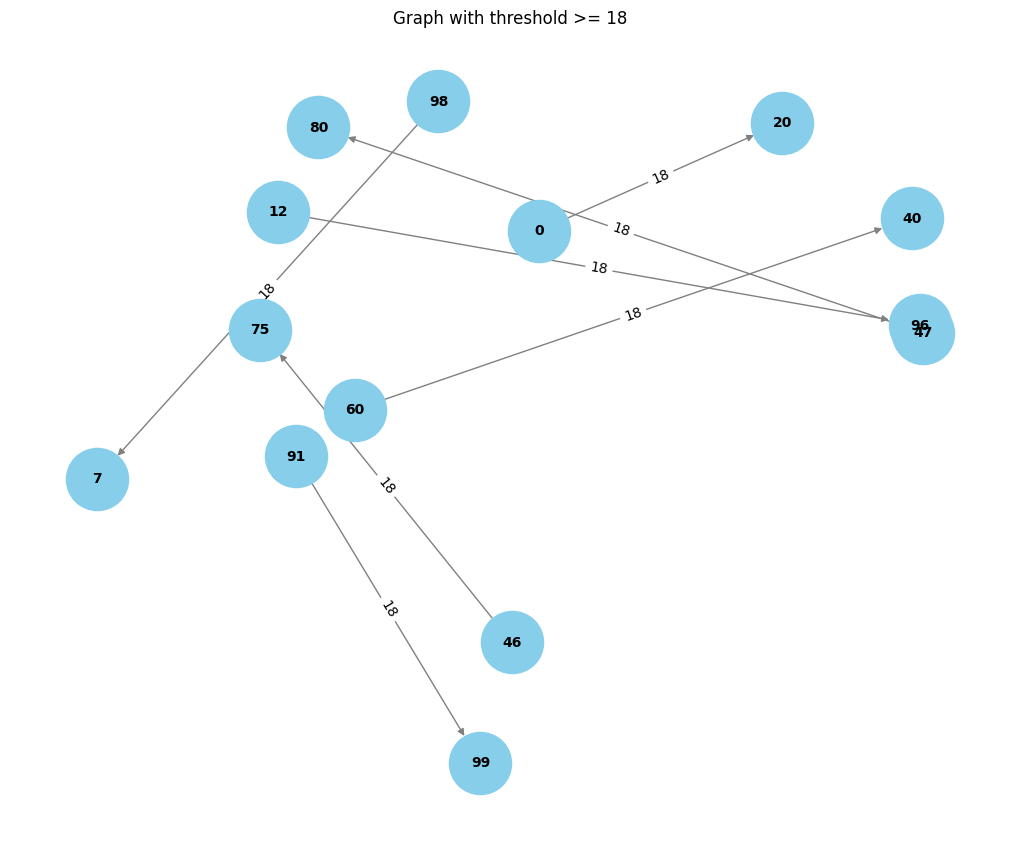

interactive(children=(IntSlider(value=18, description='threshold', max=18), Output()), _dom_classes=('widget-i…

In [43]:
plot_eq_4(df_orginal)

In [ ]:
def plot_eq_5(matrix):
    # Ensure it's a square matrix
    if matrix.shape[0] != matrix.shape[1]:
        print(matrix)
        #raise ValueError("The matrix must be square (m*m).")
    
    # Create a directed graph from the adjacency matrix
    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)
    
    # Function to filter edges and nodes based on a threshold
    def plot_filtered_graph(threshold):
        filtered_G = nx.DiGraph()
        
        # Add edges that meet the threshold
        for u, v, data in G.edges(data=True):
            weight = matrix.loc[u, v]
            if weight >= threshold:
                filtered_G.add_edge(u, v, weight=weight)
        
        # Remove isolated nodes (nodes with no edges)
        isolated_nodes = list(nx.isolates(filtered_G))
        filtered_G.remove_nodes_from(isolated_nodes)
        
        # Plot the filtered graph
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(filtered_G)
        nx.draw(filtered_G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black', font_weight='bold', edge_color='gray', arrowsize=20)
        edge_labels = nx.get_edge_attributes(filtered_G, 'weight')
        nx.draw_networkx_edge_labels(filtered_G, pos, edge_labels=edge_labels)
        plt.title(f'Graph with threshold >= {threshold}')
        plt.show()
    
    # Interactive slider for threshold selection
    max_weight = matrix.max().max()
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=int(max_weight), step=1, value=2))

In [ ]:
plot_eq_5(df_orginal)

In [ ]:
def plot_eq_6(matrix):
    # Assign default indices and column names if missing
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])
    
    # Create a directed graph from the adjacency matrix
    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)
    
    # Precompute layout for faster plotting
    pos = nx.spring_layout(G, seed=42)
    pos = {node: (x, y * -1) for node, (x, y) in pos.items()}  # Invert y-axis for upward orientation
    
    # Function to filter edges and nodes based on a threshold
    def plot_filtered_graph(threshold):
        filtered_edges = [(u, v) for u, v, data in G.edges(data=True) if matrix.loc[u, v] >= threshold]
        filtered_nodes = set(u for u, v in filtered_edges).union(v for u, v in filtered_edges)
        
        filtered_G = G.edge_subgraph(filtered_edges).copy()
        
        # Remove isolated nodes
        isolated_nodes = set(filtered_G.nodes) - filtered_nodes
        filtered_G.remove_nodes_from(isolated_nodes)
        
        # Plot the filtered graph
        plt.figure(figsize=(10, 8))
        nx.draw(filtered_G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black', font_weight='bold', edge_color='gray')
        edge_labels = nx.get_edge_attributes(filtered_G, 'weight')
        nx.draw_networkx_edge_labels(filtered_G, pos, edge_labels=edge_labels)
        plt.title(f'Graph with threshold >= {threshold}')
        plt.show()
    
    # Interactive slider for threshold selection
    max_weight = matrix.max().max()
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=int(max_weight), step=1, value=4))

In [ ]:
plot_eq_6(df_orginal)

In [ ]:
def plot_eq_7(matrix):
    # Sicherstellen, dass die Matrix passende Indizes und Spalten hat
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])

    # Directed Graph aus Adjazenzmatrix
    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)

    # Knotenpositionen einmal berechnen
    try:
        hierarchy = list(nx.topological_sort(G))
        pos = {node: (0, -i) for i, node in enumerate(hierarchy)}
    except nx.NetworkXUnfeasible:
        pos = nx.spring_layout(G, seed=42)
        pos = {node: (x, -y) for node, (x, y) in pos.items()}

    # Alle Kanten und ihre Gewichte einmal extrahieren
    all_edges = [(u, v, matrix.loc[u, v]) for u, v in G.edges()]

    # Output Widget zur besseren Kontrolle
    out = Output()

    def plot_filtered_graph(threshold):
        with out:
            out.clear_output(wait=True)

            # Kanten filtern
            filtered_edges = [(u, v) for u, v, w in all_edges if w >= threshold]
            if not filtered_edges:
                print(f"Keine Kanten mit Gewicht ≥ {threshold}")
                return

            # Teilgraph mit gefilterten Kanten
            filtered_G = G.edge_subgraph(filtered_edges).copy()

            # Plot
            plt.figure(figsize=(10, 8))
            nx.draw(
                filtered_G, pos,
                with_labels=True,
                node_color='skyblue',
                node_size=1200,
                font_size=10,
                font_color='black',
                edge_color='gray'
            )

            edge_labels = {(u, v): matrix.loc[u, v] for u, v in filtered_G.edges()}
            nx.draw_networkx_edge_labels(filtered_G, pos, edge_labels=edge_labels, font_size=8)

            plt.title(f'Graph mit Kanten-Gewicht ≥ {threshold}')
            plt.axis('off')
            plt.tight_layout()
            plt.show()

    # Interaktiver Slider zur Steuerung
    max_weight = int(matrix.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=4))
    display(out)

In [ ]:
plot_eq_7(df_orginal)

In [ ]:
pio.renderers.default = 'notebook'  # oder notebook, browser...

def plot_eq_1_plotly(matrix):
    matrix.index = range(matrix.shape[0])
    matrix.columns = range(matrix.shape[1])

    G = nx.from_pandas_adjacency(matrix, create_using=nx.DiGraph)

    try:
        pos = nx.planar_layout(G)
    except:
        pos = nx.spring_layout(G, seed=42)

    all_edges = [(u, v, matrix.loc[u, v]) for u, v in G.edges()]

    def plot_filtered_graph(threshold):
        edge_x = []
        edge_y = []
        edge_labels = []

        for u, v, w in all_edges:
            if w >= threshold:
                x0, y0 = pos[u]
                x1, y1 = pos[v]
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
                edge_labels.append(f"{u} → {v}: {w}")

        if not edge_labels:
            print(f"Keine Kanten ≥ {threshold}")
            return

        edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=1, color='gray'))

        node_x = [pos[n][0] for n in G.nodes()]
        node_y = [pos[n][1] for n in G.nodes()]
        node_text = [str(n) for n in G.nodes()]

        node_trace = go.Scatter(
            x=node_x, y=node_y, text=node_text,
            mode='markers+text', textposition='top center',
            marker=dict(size=20, color='skyblue', line=dict(width=2, color='black'))
        )

        fig = go.Figure(data=[edge_trace, node_trace])
        fig.update_layout(
            title=f'Graph mit Kanten ≥ {threshold}',
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        )

        fig.write_html("mein_plot.html")

        fig.show()

    max_weight = int(matrix.max().max())
    interact(plot_filtered_graph, threshold=IntSlider(min=0, max=max_weight, step=1, value=4))


In [ ]:
plot_eq_1_plotly(df_orginal)

In [ ]:
def objective_function(perm, matrix):
    """
    Bewertungsfunktion für simulated annealing.
    """
    perm = np.argsort(perm)
    permuted_matrix = matrix[np.ix_(perm, perm)]
    return find_symmetric_transitive_submatrices(permuted_matrix)

def optimize_permutation_simulated_annealing(matrix):
    """
    Optimiert die Permutation mit simulated annealing.
    """
    n = matrix.shape[0]
    bounds = [(0, n) for _ in range(n)]
    result = dual_annealing(objective_function, bounds, args=(matrix,))
    best_permutation = np.argsort(result.x)
    best_score = -result.fun
    return best_permutation, best_score

In [ ]:
def evaluate_population(args):
    """
    Hilfsfunktion zur parallelen Bewertung der Population.
    """
    ind, matrix = args
    return objective_function(ind, matrix)[1]

def optimize_permutation_genetic_algorithm(matrix, population_size=50, generations=100, mutation_rate=0.1, num_workers=8):
    """
    Optimiert die Permutation mit einem genetischen Algorithmus und paralleler Bewertung.
    """
    n = matrix.shape[0]
    
    # Initiale Population erzeugen
    population = [np.random.permutation(n) for _ in range(population_size)]
    
    with Pool(num_workers) as pool:
        for generation in range(generations):
            # Fitness parallel berechnen
            scores = pool.map(evaluate_population, [(ind, matrix) for ind in population])
            sorted_indices = np.argsort(scores)[::-1]
            population = [population[i] for i in sorted_indices]
            
            # Selektion (Top 50%)
            num_selected = population_size // 2
            selected = population[:num_selected]
            
            # Crossover
            children = []
            while len(children) < population_size - num_selected:
                parent1, parent2 = random.sample(selected, 2)
                crossover_point = random.randint(0, n - 1)
                child = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
                # Stelle sicher, dass das Kind eine gültige Permutation ist
                _, idx = np.unique(child, return_index=True)
                missing = set(range(n)) - set(child)
                for i in range(n):
                    if i not in idx:
                        child[i] = missing.pop()
                children.append(child)
            
            # Mutation
            for child in children:
                if random.random() < mutation_rate:
                    i, j = random.sample(range(n), 2)
                    child[i], child[j] = child[j], child[i]
            
            population = selected + children
    
    # Beste Lösung zurückgeben
    best_permutation = population[0]
    best_score = objective_function(best_permutation, matrix)
    return best_permutation, best_score

In [ ]:
# Binaer
best_perm_binaer, best_score_binaer = optimize_permutation_genetic_algorithm(matrix=matrix_np_binaer, generations=10)
print("Beste Permutation:", best_perm_binaer)
print("Beste Punktzahl:", best_score_binaer)

# Orginal
best_perm_orginal, best_score_orginal = optimize_permutation_genetic_algorithm(matrix=matrix_np_orginal, generations=10)
print("Beste Permutation:", best_perm_orginal)
print("Beste Punktzahl:", best_score_orginal)

In [ ]:
print(type(best_perm_binaer))
print(type(matrix_np_binaer))

# DataFrame nach bester Permutation sortieren
df_sorted = df.iloc[best_perm_binaer, :].iloc[:, best_perm_binaer]
print("Sortiertes DataFrame:")
print(df_sorted)
matrix_np_perm_binaer = df_sorted.to_numpy()


print(type(best_perm_orginal))
print(type(matrix_np_orginal))

# DataFrame nach bester Permutation sortieren
df_sorted = df.iloc[best_perm_orginal, :].iloc[:, best_perm_orginal]
print("Sortiertes DataFrame:")
print(df_sorted)
matrix_np_perm_orginal = df_sorted.to_numpy()